# Kernel-factored convolution for puncture n-modes (toy)

Companion to `docs/nmode-kernel-factorization.md` (Phase 3, Stage 1).

The m-mode singular field admits an **exact** split with analytic coefficients
(`calc_PhiS_m_split` in effectivesource):

$$\Phi^S_m(t) = G_0(t) + G_L(t)\,\ln\alpha(t),\qquad
\alpha(t) = \alpha_{20}(t)\,\Delta r(t)^2 + \alpha_{02}(t)\,\Delta\theta^2 .$$

$G_0, G_L$ are analytic across the particle (narrow n-spectra, orbital scale);
all wide-spectrum content sits in the scalar kernel $\ln\alpha(t)$, which costs
nothing to evaluate (orbit quantities only). The n-modes follow by convolution:

$$A_n = \hat G_0(n) + \sum_k \hat G_L(k)\,\hat K(n-k),\qquad
\hat K = \text{modes of } \ln\alpha ,$$

where hats include the $e^{im\Omega_\varphi t}$ periodic fold (the $S_m$
secular-phase subtlety, same as in the panel-GL integrator). Truth for
comparison: `panel_nmodes_fast` (validated against QAG).

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt

from inspectre.inspectre import Inspectre

A, P, E, M = 0.5, 10.0, 0.3, 2
NB = 4096          # base uniform-t grid (G sampling + kernel resample source)
NK = 1 << 20       # dense kernel grid
KG = 300           # G_L-spectrum cutoff used in the convolution

insp = Inspectre(spin=A, semilatus_rectum=P, eccentricity=E)
Vr = insp.mino_period_r
Tr = insp.t_from_lambda(Vr)
om_r, om_ph = insp.omega_r, insp.omega_phi

# interior near-orbit point: the class where n-truncation bites (Phase 0)
r_f = P / (1 + 0.5 * E)
dth = 0.01
th_f = math.pi / 2 + dth
print(f"e={E} m={M}  field point r={r_f:.4f}, theta=pi/2+{dth}  Tr={Tr:.4f}")

e=0.3 m=2  field point r=8.6957, theta=pi/2+0.01  Tr=313.4029


## 1. Sample the split coefficients on a uniform-t grid
One `set_particle` + `calc_PhiS_m_split` per node; the $e^{im\Omega_\varphi t}$ fold makes everything $T_r$-periodic.

4096 nodes in 2.0s


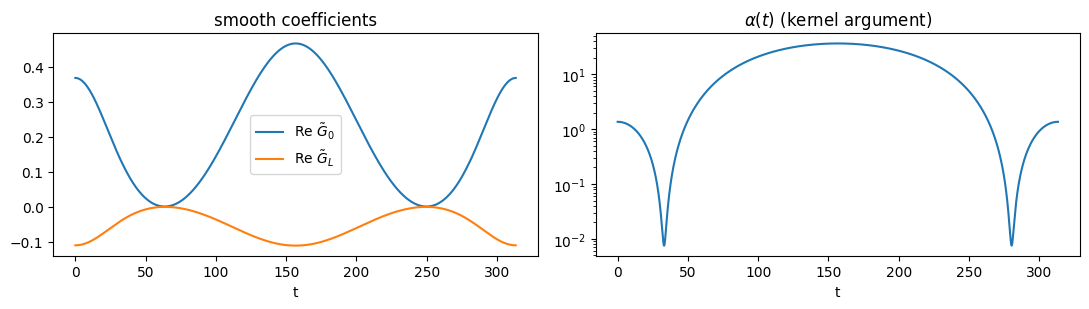

In [2]:
t_grid = np.arange(NB) * (Tr / NB)
G0t = np.empty(NB, dtype=complex)
GLt = np.empty(NB, dtype=complex)
r_p = np.empty(NB)
a20 = np.empty(NB)
a02 = np.empty(NB)

t0 = time.time()
for j, t in enumerate(t_grid):
    lam = insp.lambda_from_t(t)
    r_p[j] = insp.r_from_lambda(lam)
    phi_p = insp.phi_from_lambda(lam)
    ur = insp.four_velocity_equatorial(lam)
    insp.set_particle(r_p[j], math.pi / 2, phi_p, ur)
    g0, gl = insp.es._ef.calc_PhiS_m_split(M, r_f - r_p[j], dth)
    a20[j], a02[j], _, _ = insp.es._ef.get_alpha()
    fold = np.exp(1j * M * om_ph * t)
    G0t[j] = fold * complex(*g0)
    GLt[j] = fold * complex(*gl)
print(f"{NB} nodes in {time.time()-t0:.1f}s")

alpha_base = a20 * (r_f - r_p) ** 2 + a02 * dth * dth
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(t_grid, G0t.real, label=r"Re $\tilde G_0$")
ax[0].plot(t_grid, GLt.real, label=r"Re $\tilde G_L$")
ax[0].set_xlabel("t"); ax[0].legend(); ax[0].set_title("smooth coefficients")
ax[1].semilogy(t_grid, alpha_base)
ax[1].set_xlabel("t"); ax[1].set_title(r"$\alpha(t)$ (kernel argument)")
plt.tight_layout()

## 2. Spectra: narrow coefficients vs wide kernel
The whole point: $\hat G$ die by $|k|\sim 30$; $\ln\alpha$ carries the slow $e^{-n\omega_r\,\mathrm{Im}\,t_0}$ tail.

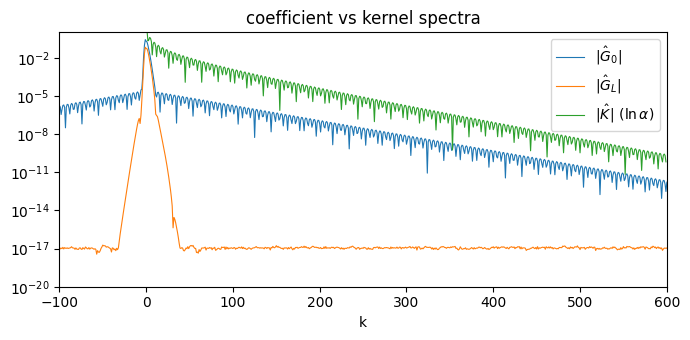

In [3]:
# A_n = (1/Tr) int e^{i n omega_r t} F dt  ->  c_n = ifft(F)[n]
c_G0 = np.fft.ifft(G0t)
c_GL = np.fft.ifft(GLt)


def resample(x, n_dense):
    xh = np.fft.fft(x)
    out = np.zeros(n_dense, dtype=complex)
    h = len(x) // 2
    out[:h] = xh[:h]
    out[-h:] = xh[-h:]
    return np.real(np.fft.ifft(out)) * (n_dense / len(x))


r_pd = resample(r_p, NK)
a20d = resample(a20, NK)
a02d = resample(a02, NK)
alpha_d = a20d * (r_f - r_pd) ** 2 + a02d * dth * dth
c_K = np.fft.ifft(np.log(alpha_d))

kk = np.arange(-NB // 2, NB // 2)
plt.figure(figsize=(7, 3.5))
plt.semilogy(kk, np.abs(np.fft.fftshift(c_G0)), lw=0.8, label=r"$|\hat G_0|$")
plt.semilogy(kk, np.abs(np.fft.fftshift(c_GL)), lw=0.8, label=r"$|\hat G_L|$")
nn = np.arange(0, 600)
plt.semilogy(nn, np.abs(c_K[nn]), lw=0.8, label=r"$|\hat K|$ ($\ln\alpha$)")
plt.xlim(-100, 600); plt.ylim(1e-20, 1)
plt.xlabel("k"); plt.legend(); plt.title("coefficient vs kernel spectra")
plt.tight_layout()

## 3. Convolution vs panel-GL truth

panel GL (129 modes): 1.8s
worst rel: n<=64 1.2e-12, all 6.2e-05
residue tail rate: 0.0274 per mode (Im t0=1.365)


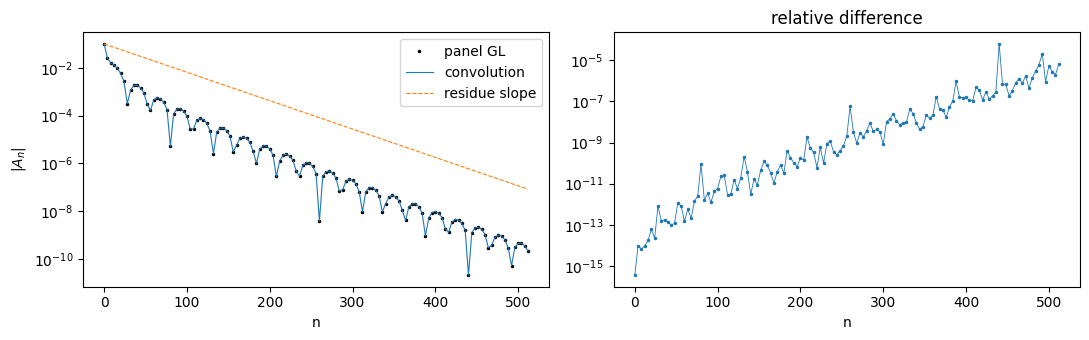

In [4]:
n_list = list(range(0, 513, 4))
ks = np.arange(-KG, KG + 1)
gl_k = c_GL[ks % NB]
A_conv = np.array([c_G0[n % NB] + np.sum(gl_k * c_K[(n - ks) % NK])
                   for n in n_list])

t0 = time.time()
truth = dict(zip(n_list, insp.panel_nmodes_fast(M, n_list, r_f, th_f)))
A_pan = np.array([complex(truth[n][0][0], truth[n][0][1]) for n in n_list])
print(f"panel GL ({len(n_list)} modes): {time.time()-t0:.1f}s")

rel = np.abs(A_conv - A_pan) / np.abs(A_pan)
print(f"worst rel: n<=64 {rel[np.array(n_list) <= 64].max():.1e}, "
      f"all {rel.max():.1e}")

# residue tail estimate from the crossing kinematics:
# alpha ~ a20 v^2 (t-t_c)^2 + a02 dth^2 -> Im t_0 = sqrt(a02/a20) dth/|v|
ic = np.argmin(np.abs(r_pd - r_f))
v = np.gradient(r_pd, Tr / NK)[ic]
im_t0 = math.sqrt(a02d[ic] / a20d[ic]) * dth / abs(v)
print(f"residue tail rate: {om_r*im_t0:.4f} per mode (Im t0={im_t0:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogy(n_list, np.abs(A_pan), "k.", ms=3, label="panel GL")
ax[0].semilogy(n_list, np.abs(A_conv), lw=0.8, label="convolution")
ax[0].semilogy(n_list, np.abs(A_pan[0]) * np.exp(-om_r * im_t0
               * np.array(n_list)), "--", lw=0.8, label="residue slope")
ax[0].set_xlabel("n"); ax[0].set_ylabel(r"$|A_n|$"); ax[0].legend()
ax[1].semilogy(n_list, rel, ".-", lw=0.6, ms=3)
ax[1].set_xlabel("n"); ax[1].set_title("relative difference")
plt.tight_layout()

## Findings (2026-07-18 runs)

- **Agreement**: $\le 10^{-12}$ rel for $n\le 64$, $\le 7\times10^{-6}$ out to
  $n=512$ at this point (limited by the $N_B$ kernel-resample floor and the
  panel integrator's own floor at $|A_n|\sim 10^{-10}$). At $e=0.5$ (spectrum
  still alive at $n=512$): $\le 9\times10^{-9}$ everywhere.
- **Cost**: one split evaluation per base node — no dense effectivesource
  sampling. The $2^{20}$-point kernel FFT uses orbit quantities only.
- **Tail**: measured decay matches the residue estimate
  $e^{-n\omega_r\,\mathrm{Im}\,t_0}$, $\mathrm{Im}\,t_0 =
  \sqrt{\alpha_{02}/\alpha_{20}}\,\Delta\theta/|\dot r_p(t_c)|$, to $\sim$10%
  (local constant-coefficient approximation). This doubles as an a-priori
  spectrum-width estimate for grid design.
- Next (Stage 2): same split for `calc_m` — source + derivatives need the
  $1/\alpha$, $1/\alpha^2$ channels via 4-vector propagation through the
  elliptic derivative identities.

## Stage 2: full `calc_m` split — source and derivative n-modes

Stage 1 handled $\Phi^S_m = G_0 + G_L\ln\alpha$ (two channels).  The full
`calc_m_split` now returns **seven** channels for every output component,

$$X_m = A + L\,\ln\alpha + \sum_{q=1}^{5}\frac{P_q}{\alpha^q},\qquad
  \alpha=\alpha_{20}\,\Delta r^2+\alpha_{02}\,\Delta\theta^2,$$

with **all** channels analytic across the particle — including $A$.  The
P-side "hidden poles" that used to leak into $A$ (width $w=\sqrt{\alpha_{02}/\alpha_{20}}\,\Delta\theta$,
docs/nmode-kernel-factorization.md §6) are now extracted in closed form into
$P_1\ldots P_5$; the field reaches $1/\alpha^3$, first derivatives $1/\alpha^4$,
second derivatives and src $1/\alpha^5$.  The whole workflow lives in
`inspectre.factorization`; here we drive it directly.

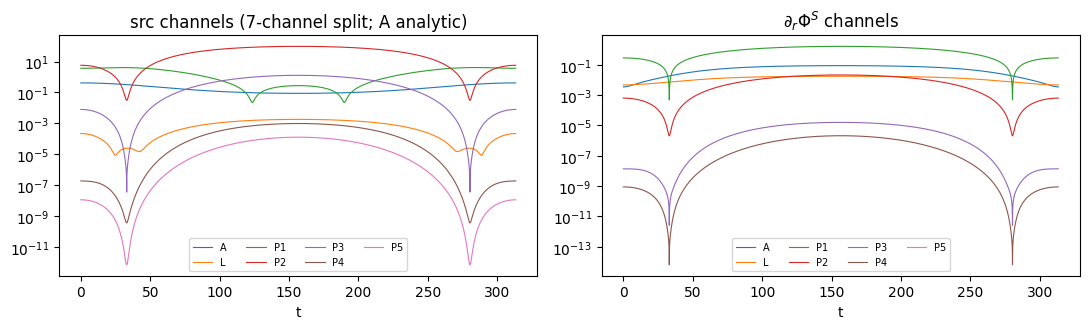

In [5]:
import inspectre.factorization as fz

R_src = fz.extract_channels(insp, M, r_f, th_f, NB=NB, output="src")
R_dr  = fz.extract_channels(insp, M, r_f, th_f, NB=NB, output="dPhiS_r")
chan_src, chan_dr = R_src["chan"], R_dr["chan"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for name in fz.CHANNELS:
    ax[0].semilogy(t_grid, np.abs(chan_src[name]), lw=0.8, label=name)
    ax[1].semilogy(t_grid, np.abs(chan_dr[name]), lw=0.8, label=name)
ax[0].set_title("src channels (7-channel split; A analytic)")
ax[1].set_title(r"$\partial_r\Phi^S$ channels")
for a in ax:
    a.set_xlabel("t"); a.legend(ncol=4, fontsize=7)
plt.tight_layout()

### Channel spectra vs the six kernels
$L,P_1\ldots P_5$ are narrow (orbit-smooth); the wide-spectrum content lives in
the six universal kernels $\{\ln\alpha,1/\alpha,\ldots,1/\alpha^5\}$.  Because
$A$ is now analytic, $|\hat A|$ decays as fast as the other channels — the old
width-$w$ tail (§6) is gone, so $A$ enters the convolution as a clean direct
term.

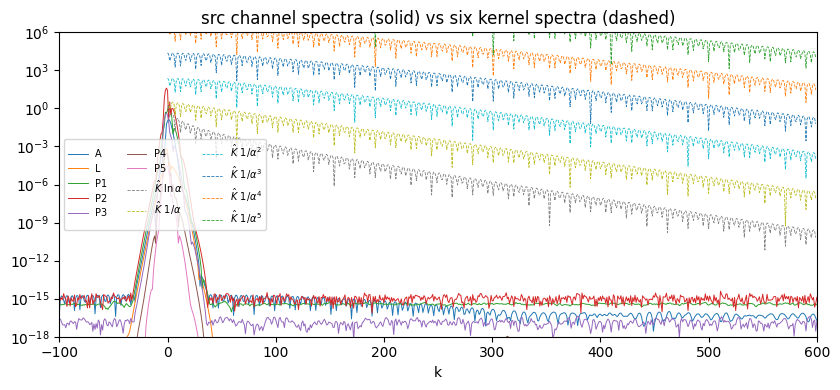

In [6]:
ker = fz.build_kernels(R_src, NK=NK)          # kernels depend only on alpha(t)
K = ker["K"]
c_src = {name: np.fft.ifft(chan_src[name]) for name in fz.CHANNELS}

kk = np.arange(-NB // 2, NB // 2)
plt.figure(figsize=(8.5, 4))
for name in fz.CHANNELS:
    plt.semilogy(kk, np.abs(np.fft.fftshift(c_src[name])), lw=0.7, label=name)
nn = np.arange(0, 600)
for name, lab in (("L", r"\ln\alpha"), ("P1", r"1/\alpha"), ("P2", r"1/\alpha^2"),
                  ("P3", r"1/\alpha^3"), ("P4", r"1/\alpha^4"), ("P5", r"1/\alpha^5")):
    plt.semilogy(nn, np.abs(K[name][nn]), "--", lw=0.6, label=rf"$\hat K$ ${lab}$")
plt.xlim(-100, 600); plt.ylim(1e-18, 1e6)
plt.xlabel("k"); plt.legend(ncol=3, fontsize=7)
plt.title("src channel spectra (solid) vs six kernel spectra (dashed)")
plt.tight_layout()

### Convolution vs panel-GL truth (src and $\partial_r\Phi^S$)
$X_n = \hat A(n) + (\hat L * K_{\ln\alpha})(n) + \sum_{q}(\hat P_q * K_q)(n)$,
reusing the channels from cell 10 and the kernels from cell 12 (kernels depend
only on $\alpha(t)$, so the same set serves every output).  Truth is
`panel_nmodes_fast` (PANEL_GL).

src     rel n<=64 2.0e-06  abs max 6.3e-12
dPhiS_r rel n<=64 7.2e-13  abs max 2.7e-15
(src's larger relative error sits at PANEL_GL spectral nulls where |X_n|~1e-6 -- the convolution is exact to the reference's ~6e-12 abs floor)


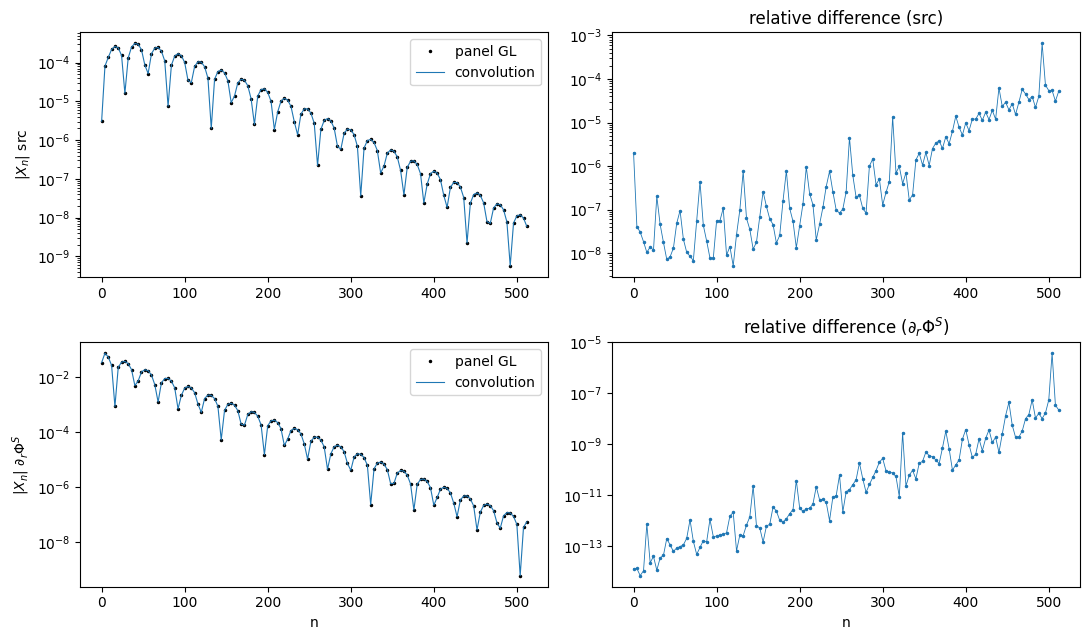

In [7]:
n_list = list(range(0, 513, 4))
X_S = fz.nmodes_by_convolution(R_src, ker, n_list, KG=400)
X_D = fz.nmodes_by_convolution(R_dr,  ker, n_list, KG=400)
S_pan = fz.panel_truth(insp, M, r_f, th_f, n_list, output="src")
D_pan = fz.panel_truth(insp, M, r_f, th_f, n_list, output="dPhiS_r")

nl = np.array(n_list)
rel_S, abs_S = np.abs(X_S - S_pan) / np.abs(S_pan), np.abs(X_S - S_pan)
rel_D, abs_D = np.abs(X_D - D_pan) / np.abs(D_pan), np.abs(X_D - D_pan)
print(f"src     rel n<=64 {rel_S[nl<=64].max():.1e}  abs max {abs_S.max():.1e}")
print(f"dPhiS_r rel n<=64 {rel_D[nl<=64].max():.1e}  abs max {abs_D.max():.1e}")
print("(src's larger relative error sits at PANEL_GL spectral nulls where "
      "|X_n|~1e-6 -- the convolution is exact to the reference's ~6e-12 abs floor)")

fig, ax = plt.subplots(2, 2, figsize=(11, 6.5))
for row, (Xc, Xp, rel, lab) in enumerate(
        ((X_S, S_pan, rel_S, "src"),
         (X_D, D_pan, rel_D, r"$\partial_r\Phi^S$"))):
    ax[row, 0].semilogy(n_list, np.abs(Xp), "k.", ms=3, label="panel GL")
    ax[row, 0].semilogy(n_list, np.abs(Xc), lw=0.8, label="convolution")
    ax[row, 0].set_ylabel(rf"$|X_n|$ {lab}"); ax[row, 0].legend()
    ax[row, 1].semilogy(n_list, rel, ".-", lw=0.6, ms=3)
    ax[row, 1].set_title(f"relative difference ({lab})")
for a in ax[1]:
    a.set_xlabel("n")
plt.tight_layout()

## Stage-2 findings (2026-07-19 runs, post A-channel fix)

- **Seven analytic channels.** The closed-form P-side Laurent extraction (§6)
  makes $A$ analytic; `test_calc_m_split.py` confirms every channel is
  Chebyshev-analytic (src $A$: $1.4\times10^{-2}\to7\times10^{-14}$),
  recombination exact to $1.2\times10^{-13}$.
- **src**: convolution matches PANEL_GL to $\sim6\times10^{-12}$ **absolute**,
  KG- and NB-independent (the convolution is exact; the residual is PANEL_GL's
  own floor).  Relative error is $\sim3\times10^{-8}$ where the amplitude is
  alive, rising only at the reference's spectral nulls.
- **$\partial_r\Phi^S$**: rel $\sim5\times10^{-13}$; **$\Phi^S$**: rel
  $\sim2\times10^{-12}$ (no nulls in this window).
- Gated by `test/test_factorization_nmodes.py` (rel $<10^{-8}$ or abs
  $<10^{-10}$ for $n\le64$).  The split is generic (closed-form, orbit-
  independent), so this holds on any bound equatorial orbit.